### Importación de Librerias

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Creacion del dataframe

In [12]:
df_path = r"C:\Users\ivanf\Documents\Vortex\1.3 Vortex - Medical Cost\data\insurance.csv" ##Ubicar r antes de las comillas para evitar errroes de lectura con los backslashs
df_insurance = pd.read_csv(df_path)
print(df_insurance)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


## Metodos Estadisticos

#### Dimensionalidad de los datos

In [13]:
df_insurance.shape

(1338, 7)

#### Descripción de los datos, tipos de datos, valores nulos, etc.

In [14]:
df_insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


#### Estadísticas descriptivas

In [15]:
df_insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Histograma Distribucion de los costos

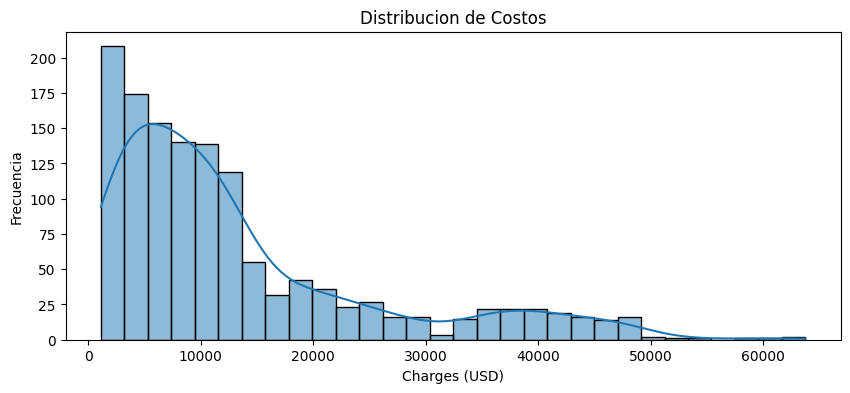

In [16]:
plt.figure(figsize=(10,4))

sns.histplot(data = df_insurance, x = 'charges', bins=30, kde=True)


plt.title('Distribucion de Costos')
plt.xlabel('Charges (USD)')
plt.ylabel('Frecuencia')
plt.show()

### Histograma Distribución de costos (Aperturado por Smokers)

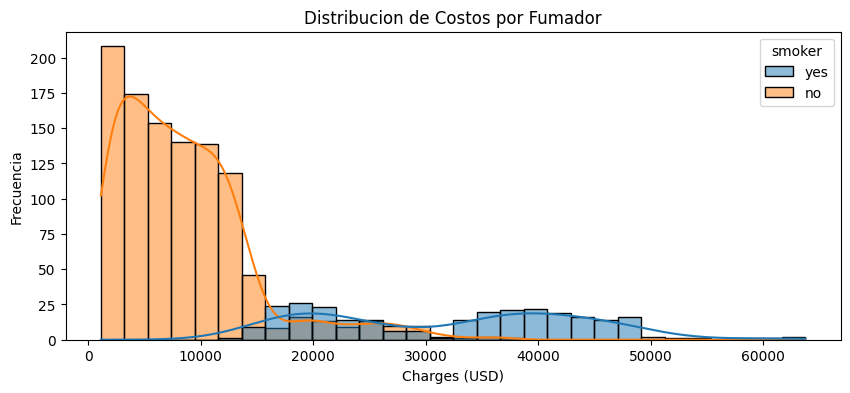

In [17]:
plt.figure(figsize=(10,4))

sns.histplot(data = df_insurance, x = 'charges', bins=30, kde=True, hue='smoker')


plt.title('Distribucion de Costos por Fumador')
plt.xlabel('Charges (USD)')
plt.ylabel('Frecuencia')
plt.show()

### Histograma Distribución de BMI (Aperturado por Smokers)

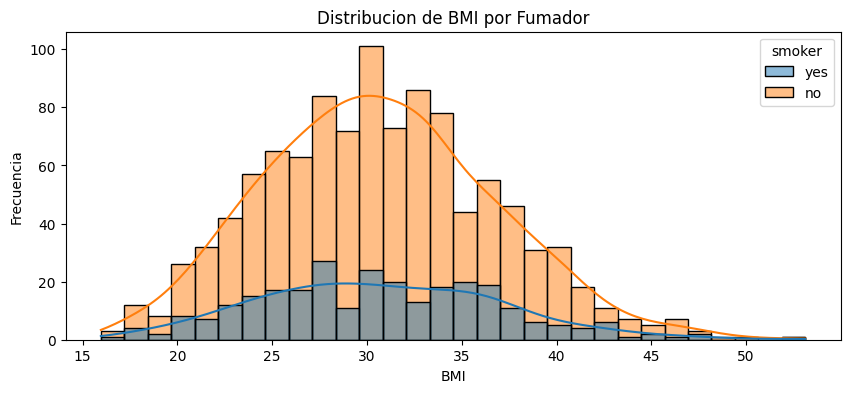

In [18]:
plt.figure(figsize=(10,4))

sns.histplot(data = df_insurance, x = 'bmi', bins=30, kde=True, hue='smoker')


plt.title('Distribucion de BMI por Fumador')
plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.show()

### Diagrama de dispersión entre BMI y Costos (Aperturado por Smokers)

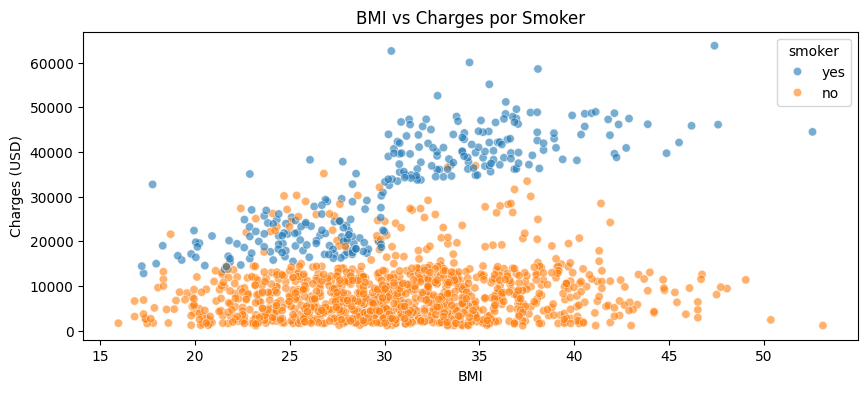

In [19]:
plt.figure(figsize=(10,4))

sns.scatterplot(data=df_insurance, x='bmi', y='charges', hue='smoker', alpha=0.6)

plt.title('BMI vs Charges por Smoker')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.show()

### Diagrama de dispersion entre Edad y Costos (Aperturado por Smokers)

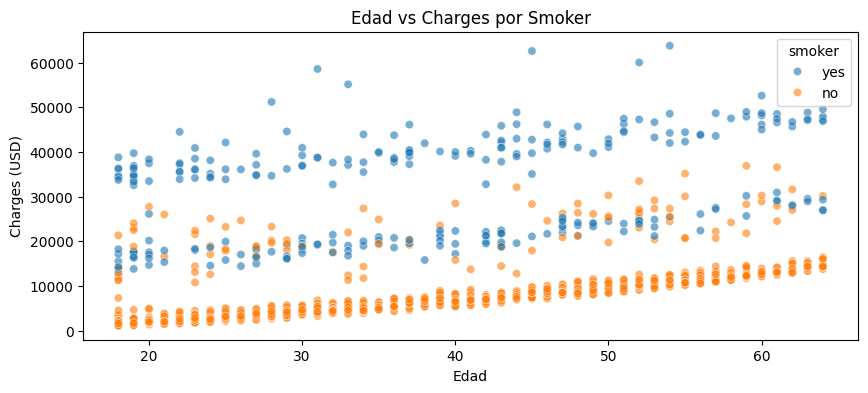

In [20]:
plt.figure(figsize=(10,4))

sns.scatterplot(data=df_insurance, x='age', y='charges', hue='smoker', alpha=0.6)

plt.title('Edad vs Charges por Smoker')
plt.xlabel('Edad')
plt.ylabel('Charges (USD)')
plt.show()

### Creacion del campo Obese a partir del campo BMI

In [22]:
df_insurance['obese'] = (df_insurance['bmi'] >= 30).astype(int)
print(df_insurance)

      age     sex     bmi  children smoker     region      charges  obese
0      19  female  27.900         0    yes  southwest  16884.92400      0
1      18    male  33.770         1     no  southeast   1725.55230      1
2      28    male  33.000         3     no  southeast   4449.46200      1
3      33    male  22.705         0     no  northwest  21984.47061      0
4      32    male  28.880         0     no  northwest   3866.85520      0
...   ...     ...     ...       ...    ...        ...          ...    ...
1333   50    male  30.970         3     no  northwest  10600.54830      1
1334   18  female  31.920         0     no  northeast   2205.98080      1
1335   18  female  36.850         0     no  southeast   1629.83350      1
1336   21  female  25.800         0     no  southwest   2007.94500      0
1337   61  female  29.070         0    yes  northwest  29141.36030      0

[1338 rows x 8 columns]


### Transformacion Smokers a variable numerica

In [23]:
df_insurance['smoker'] = (df_insurance['smoker'] == "yes").astype(int)
print(df_insurance)

      age     sex     bmi  children  smoker     region      charges  obese
0      19  female  27.900         0       1  southwest  16884.92400      0
1      18    male  33.770         1       0  southeast   1725.55230      1
2      28    male  33.000         3       0  southeast   4449.46200      1
3      33    male  22.705         0       0  northwest  21984.47061      0
4      32    male  28.880         0       0  northwest   3866.85520      0
...   ...     ...     ...       ...     ...        ...          ...    ...
1333   50    male  30.970         3       0  northwest  10600.54830      1
1334   18  female  31.920         0       0  northeast   2205.98080      1
1335   18  female  36.850         0       0  southeast   1629.83350      1
1336   21  female  25.800         0       0  southwest   2007.94500      0
1337   61  female  29.070         0       1  northwest  29141.36030      0

[1338 rows x 8 columns]


### Matriz de correlación entre las variables planteadas en la hipotesis

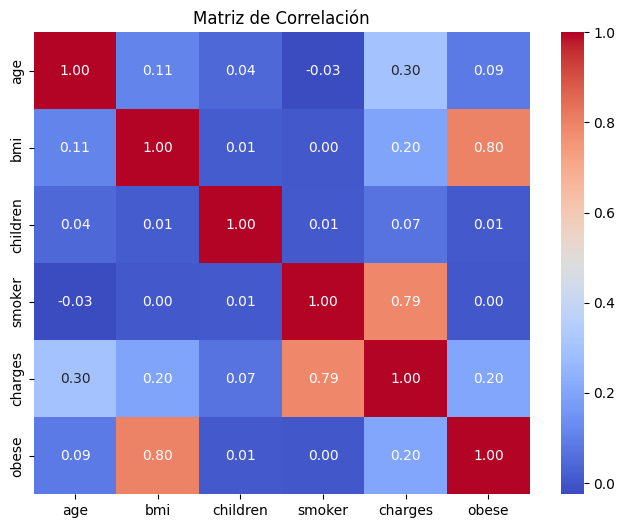

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(df_insurance.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')

plt.title('Matriz de Correlación')
plt.show()